# Runtime: < 1min

# Imports

In [1]:
import pandas as pd
import json
import geojson
import csv
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from shapely.geometry import Point, Polygon
import requests
import time
import sys
import ast
from alphashape import alphashape
import geopandas as gpd
import os
from collections import defaultdict
import os.path
from tqdm import tqdm

# Parameters

In [2]:
idx = -1

my_states = ["New Mexico", "Massachusetts", "Ohio", "Texas", "Florida", "Washington", "Illinois", "New Mexico"]
state_name = my_states[idx]


my_cities = ["Albuquerque", "Boston", "Cleveland", "Dallas", "Miami", "Seattle", "Chicago", "Santa Fe"]
city_name = my_cities[idx]

re_gen = True

In [3]:
# Ensure working directory is repo root (parent of city_data_generation/)
if os.path.basename(os.getcwd()) == "city_data_generation":
    os.chdir("..")

data_dir = os.path.join("data_real", city_name.lower().replace(" ", "_"))
os.makedirs(data_dir, exist_ok=True)

# See directory content
print("cwd:", os.getcwd())
print("data_dir:", os.path.abspath(data_dir))
print("Files:", os.listdir(data_dir))

cwd: /Users/colinkula/Desktop/SDP/QuantumVRP
data_dir: /Users/colinkula/Desktop/SDP/QuantumVRP/data_real/santa_fe
Files: ['images', 'Pickup Point Data', 'Drop Point Data', 'census', 'raw', 'stats']


# Finding Hotspot Locations
Based on the analysis, the hotspot location is chosen as center (mean) of the location within the tract. We first store these locations in a seperate `.geojson` file

In [4]:
from shapely import distance as shapely_distance

with open(data_dir + "/census/census_tract_wise_locations.json", 'r') as f:
  data = json.load(f)

tract_id = list()
hotspot_geometry = list()
num_locations = list()

# Calculate hotspots
# Loop thru all census tracts
for census_tract in data:
  lat = []
  lon = []
  # Loop thru all points
  for point in data[census_tract]:
    # Retrieve lat and lon
    lat.append(point["lat"])
    lon.append(point["lon"])

  # Allow for vectorized operartions
  lat = pd.Series(lat)
  lon = pd.Series(lon)
  # Get the average lat and lon
  hotspot_lat = lat.mean()
  hotspot_lon = lon.mean()
  # Add GEOID to track_id list
  tract_id.append(census_tract)
  # Store geometric point objects
  # Stored (lon,lat)
  hotspot_geometry.append(Point(hotspot_lon,hotspot_lat))
  # Store count
  num_locations.append(len(data[census_tract]))



# Adds hotspots to empty tracts
# Loads census tract data into geopandas dataframe
census_df = gpd.read_file(data_dir + "/census/census_tract_data.geojson")

# Track the number of empty tracts
num_empty_tracts = 0

# Loop thru every official census tract
for index, row in census_df.iterrows():
    # Get the geoid
    GEOID = row['GEOID']

    # This means this tract has zero recoreded delivery locations
    if GEOID not in tract_id:
        # Counter
        num_empty_tracts += 1
        # Get the center of the polygon
        centroid = row['geometry'].centroid
        # Store the geoid
        tract_id.append(GEOID)
        # This is a little confusing, centroid is considered a Point object?
        hotspot_geometry.append(centroid)
        # Mark it so we know nothing is in there
        num_locations.append(0)

# Create new geodataframe with the lists we collected
tract_gdf = gpd.GeoDataFrame({'GEOID': tract_id, 'geometry': hotspot_geometry, 'locations': num_locations}, crs='EPSG:4326')

# IMPORTANT: This line of code below is added to remove any outlier hotspot that appear far outside city bounds. This issue happened when generating hotspots for LA
#   This is a temporary fix. One of the hotspots generates in the wrong spot, and this removes it.
tract_gdf = tract_gdf[shapely_distance(tract_gdf['geometry'], tract_gdf.unary_union.centroid) <= 5]

tract_gdf.to_file(data_dir + '/hotspot_data.geojson', driver='GeoJSON')

/var/folders/l2/0cks6r0s55j26mlk150352_00000gn/T/ipykernel_20775/2270397049.py:67: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  tract_gdf = tract_gdf[shapely_distance(tract_gdf['geometry'], tract_gdf.unary_union.centroid) <= 5]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


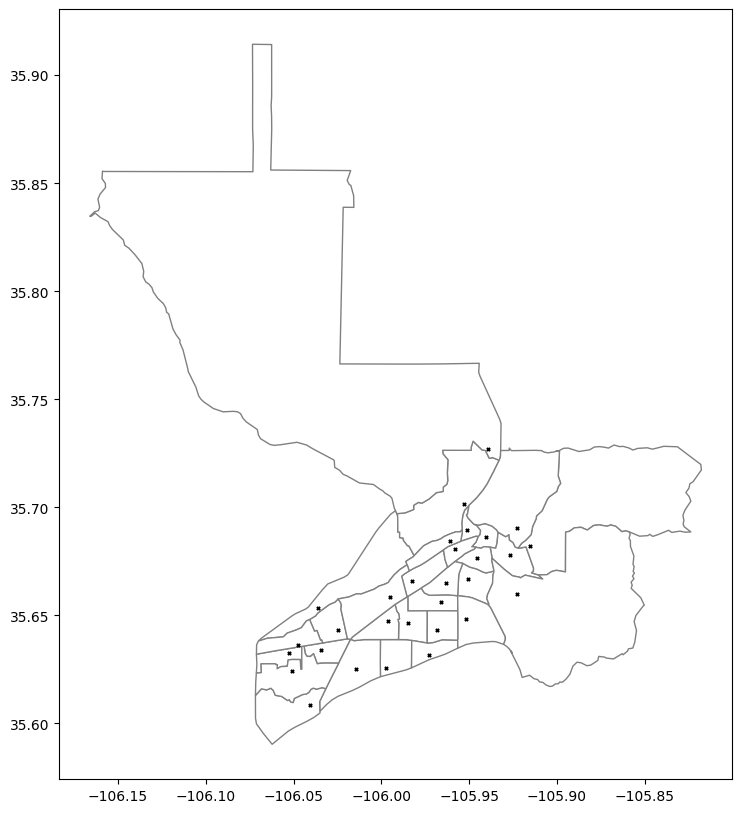

In [5]:
census_dir = data_dir + "/census/census_tract_data.geojson"
census_df = gpd.read_file(census_dir, crs='EPSG:4326')

hotspot_dir = data_dir + "/hotspot_data.geojson"
hotspot_locations = gpd.read_file(hotspot_dir, crs='EPSG:4326')

size = (10, 10)
tract = gpd.GeoSeries(census_df.loc[:].geometry)
base = tract.plot(color="white", edgecolor="gray", figsize=size)
hotspot_locations.plot(ax = base, marker='x', color='black', markersize=5, figsize=size)
os.makedirs(data_dir + "/images", exist_ok=True)
out = data_dir + "/images/city_base.png"
plt.savefig(out, bbox_inches='tight')
plt.show()
plt.close()

In [6]:
with open (data_dir + "/census/census_tract_wise_locations.json", 'r') as f:
  data = json.load(f)

with open (data_dir + "/census/census_frequency.csv", 'w') as f:
  writer = csv.writer(f)
  for census_tract in data:
    writer.writerow([census_tract,len(data[census_tract])])

# Store Metrics

In [7]:
stats_dir_path = os.path.join(data_dir, "stats")
stats_path = os.path.join(stats_dir_path, "stats.json")
stats_data = {}

# Stats dir create
os.makedirs(stats_dir_path, exist_ok=True)

# Stats load
if os.path.exists(stats_path):
    try:
        with open(stats_path, 'r') as f:
            stats_data = json.load(f)
    except Exception as e:
        print("Cant load stats file")

stats_data["total_empty_tracts"] = num_empty_tracts

try:
    with open(stats_path, 'w') as f:
        json.dump(stats_data, f, indent=4)
    print("Successful update to stats file")
except Exception as e:
    print("MAJOR: Cant write to stats file")

Successful update to stats file
